In [1]:
import warnings
warnings.filterwarnings("ignore")

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Data

In [3]:
df = pd.read_csv("ElectionData.csv")
print("Shape of dataset:", df.shape)
print(df.info())

Shape of dataset: (21643, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21643 entries, 0 to 21642
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TimeElapsed               21643 non-null  int64  
 1   time                      21643 non-null  object 
 2   territoryName             21643 non-null  object 
 3   totalMandates             21643 non-null  int64  
 4   availableMandates         21643 non-null  int64  
 5   numParishes               21643 non-null  int64  
 6   numParishesApproved       21643 non-null  int64  
 7   blankVotes                21643 non-null  int64  
 8   blankVotesPercentage      21643 non-null  float64
 9   nullVotes                 21643 non-null  int64  
 10  nullVotesPercentage       21643 non-null  float64
 11  votersPercentage          21643 non-null  float64
 12  subscribedVoters          21643 non-null  int64  
 13  totalVoters               21643

# Handle Missing Values

In [4]:
print("\nMissing Values Before:\n", df.isnull().sum())


Missing Values Before:
 TimeElapsed                 0
time                        0
territoryName               0
totalMandates               0
availableMandates           0
numParishes                 0
numParishesApproved         0
blankVotes                  0
blankVotesPercentage        0
nullVotes                   0
nullVotesPercentage         0
votersPercentage            0
subscribedVoters            0
totalVoters                 0
pre.blankVotes              0
pre.blankVotesPercentage    0
pre.nullVotes               0
pre.nullVotesPercentage     0
pre.votersPercentage        0
pre.subscribedVoters        0
pre.totalVoters             0
Party                       0
Mandates                    0
Percentage                  0
validVotesPercentage        0
Votes                       0
Hondt                       0
FinalMandates               0
dtype: int64


# Encode Categorical Columns 

In [5]:
cat_cols = df.select_dtypes(include='object').columns
print("\nCategorical columns:", cat_cols.tolist())

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


Categorical columns: ['time', 'territoryName', 'Party']


# Feature Scaling

In [6]:
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Visualization BEFORE Outlier Removal

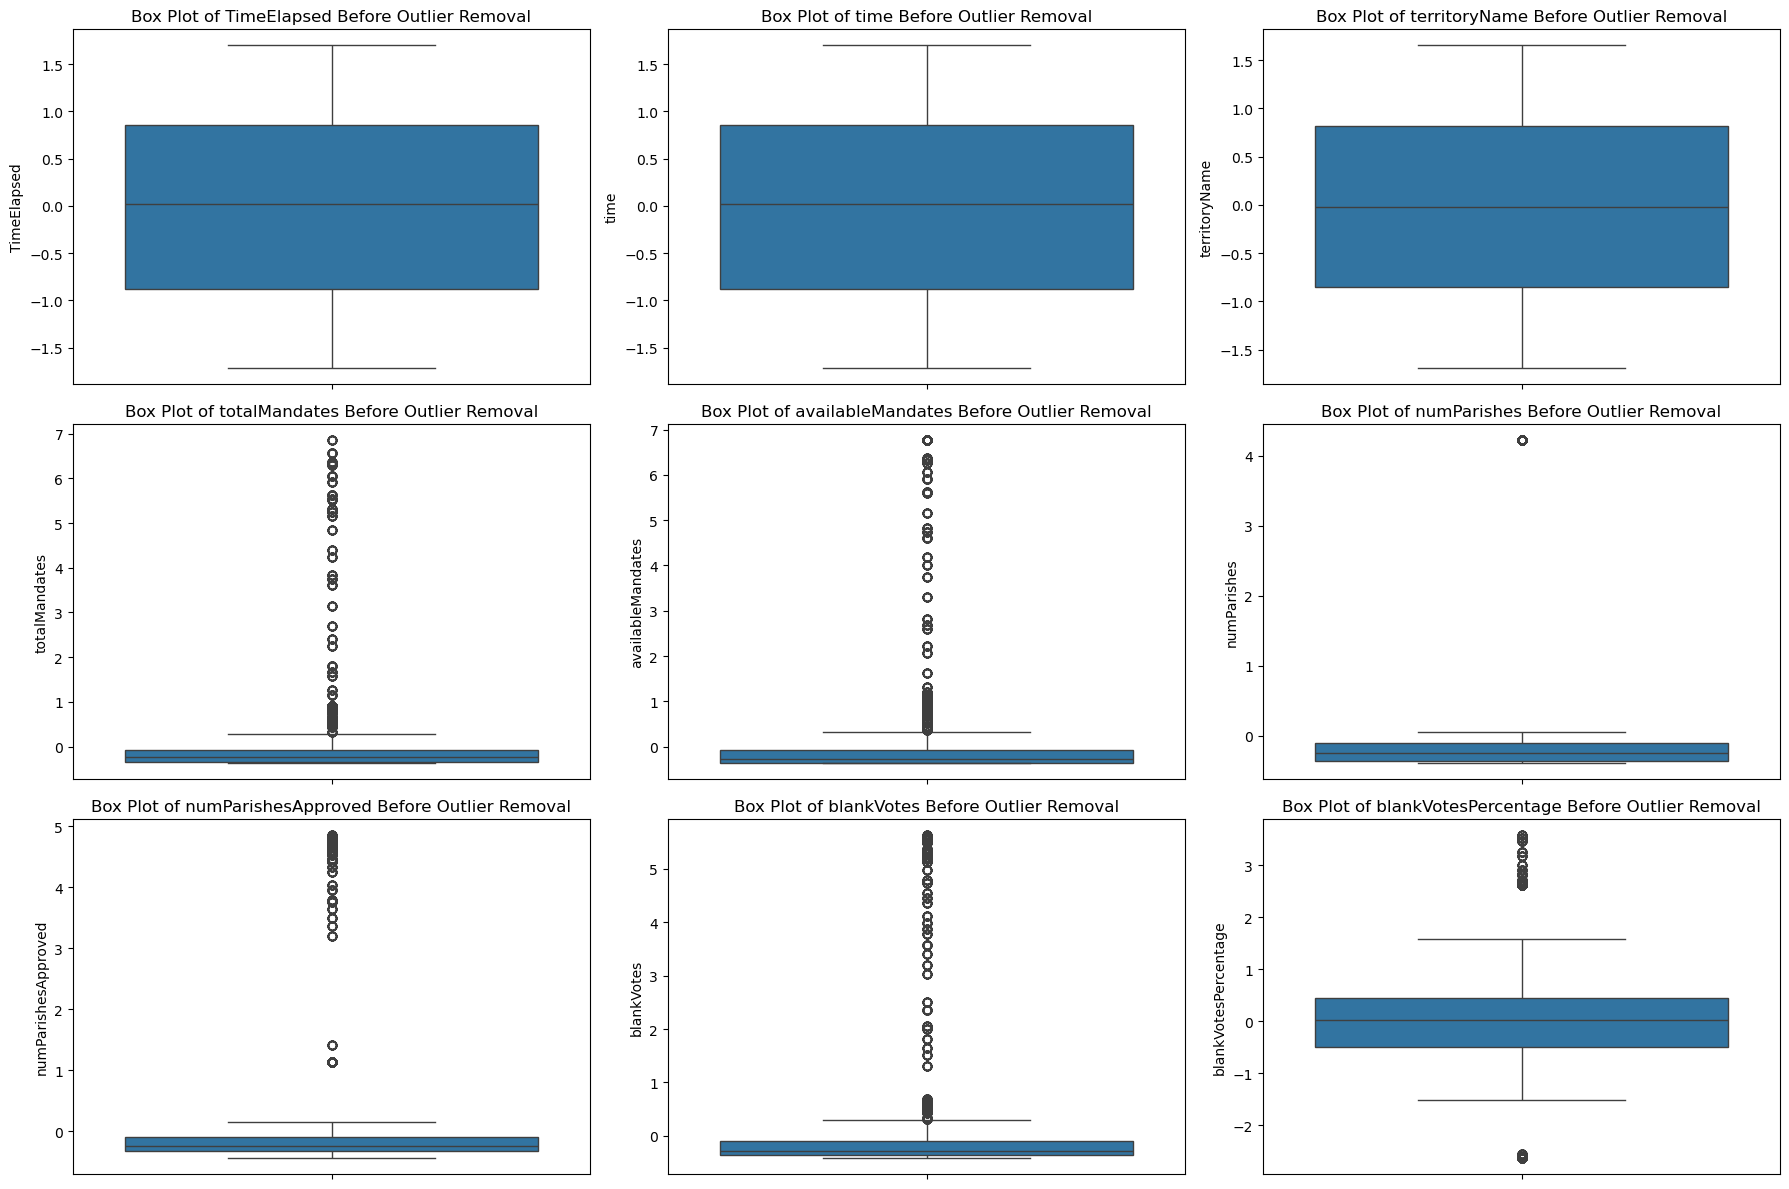

In [7]:
plt.figure(figsize=(18, 12))
for idx, col in enumerate(scaled_df.columns[:9]):
    plt.subplot(3, 3, idx+1)
    sns.boxplot(y=scaled_df[col])
    plt.title(f'Box Plot of {col} Before Outlier Removal')
plt.tight_layout()
plt.show()

# Detect and Remove Outliers using IQR

In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

In [9]:
# Only keep rows within 1.5 * IQR
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("\nShape after outlier removal:", df_clean.shape)


Shape after outlier removal: (12676, 28)


# Visualization AFTER Outlier Removal

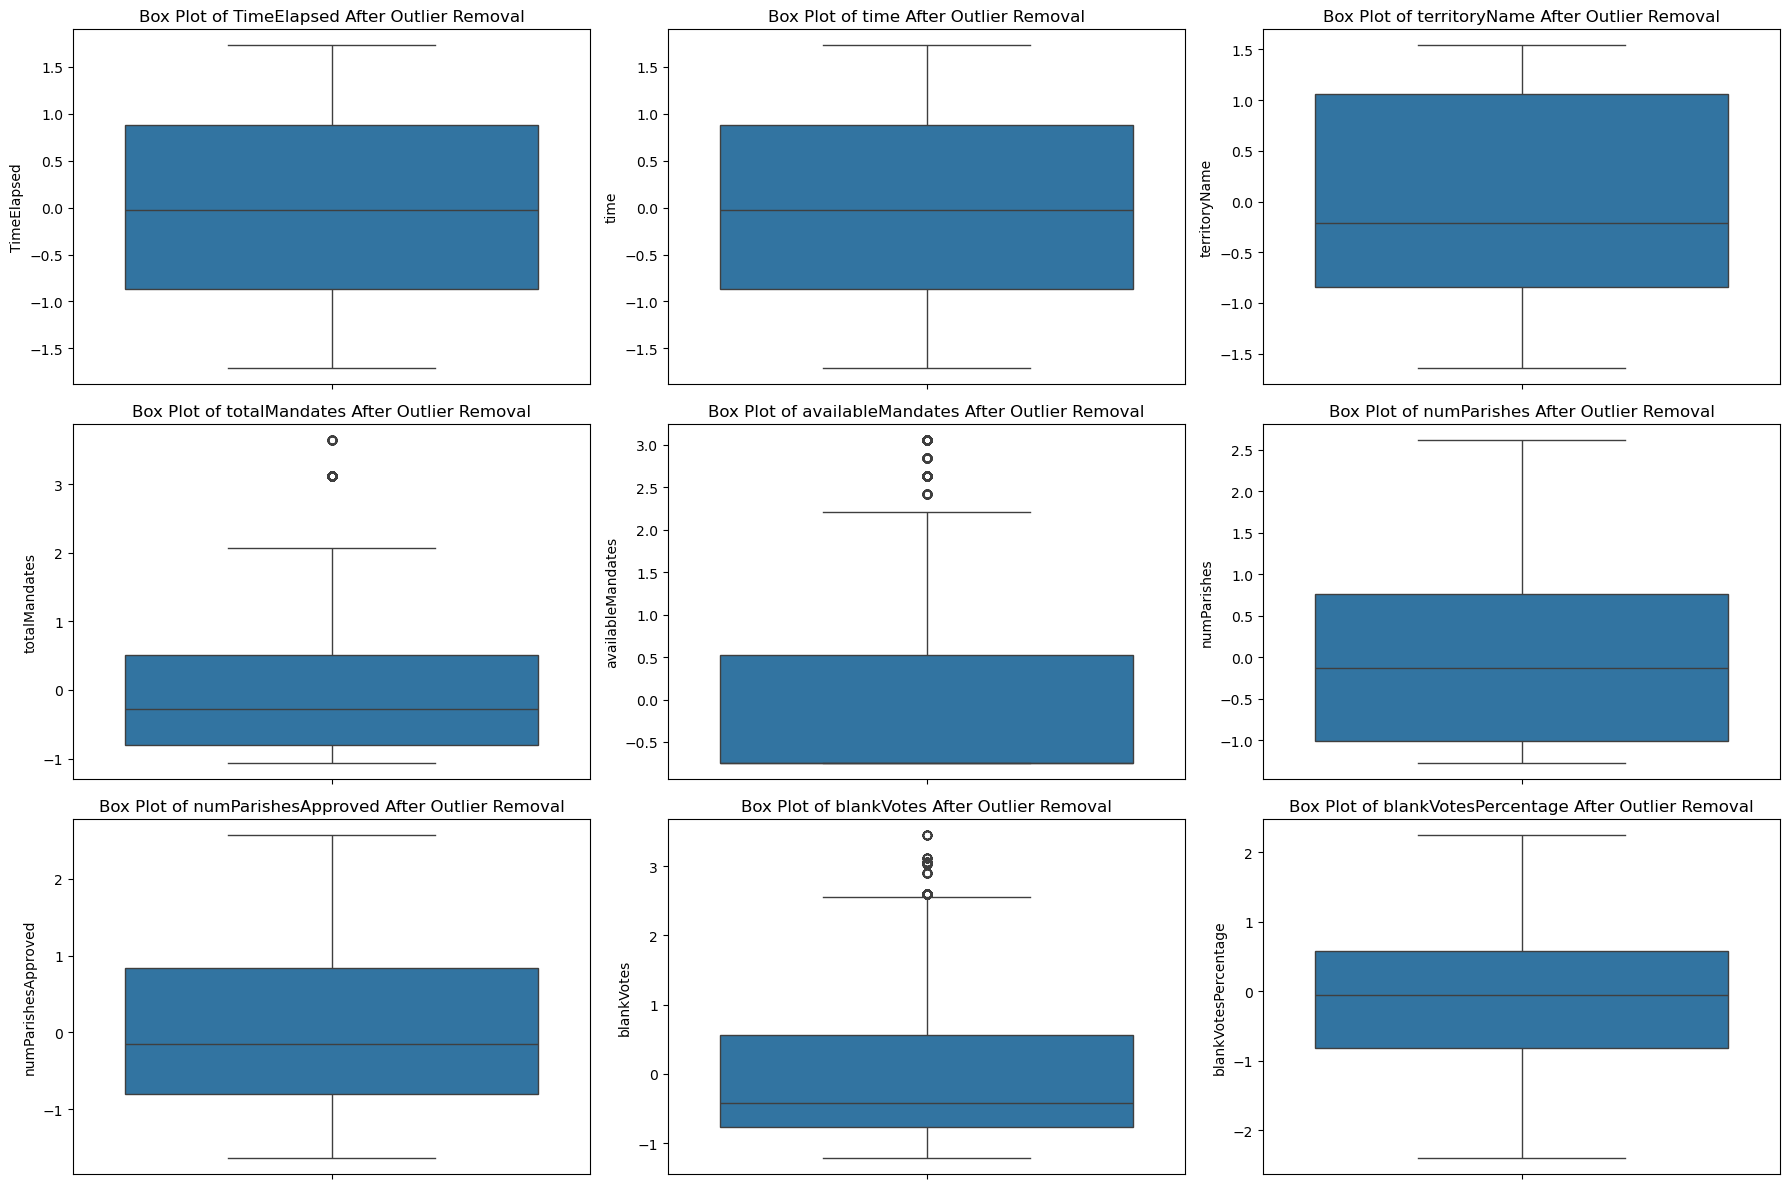

In [10]:
scaled_df_clean = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

plt.figure(figsize=(18, 12))
for idx, col in enumerate(scaled_df_clean.columns[:9]):
    plt.subplot(3, 3, idx+1)
    sns.boxplot(y=scaled_df_clean[col])
    plt.title(f'Box Plot of {col} After Outlier Removal')
plt.tight_layout()
plt.show()

# Feature-Target Split 

In [11]:
target_column = 'Votes'  
y = df_clean[target_column]
X = df_clean.drop(target_column, axis=1)

# Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Multiple Regression Models

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = {}

In [14]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2_Score': r2}

#  Compare Results

In [15]:
results_df = pd.DataFrame(results).T
print("\nModel Performance:\n", results_df)


Model Performance:
                          RMSE  R2_Score
Linear Regression  935.776582  0.735000
Ridge Regression   929.494955  0.738546
Lasso Regression   931.394748  0.737476
Decision Tree       68.988421  0.998560
Random Forest       65.286374  0.998710


# Plotting Model Performance

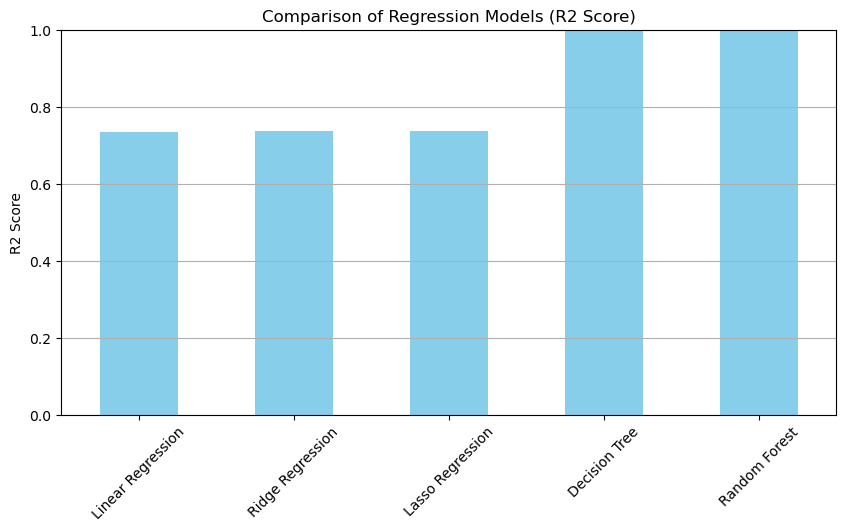

In [16]:
plt.figure(figsize=(10,5))
results_df['R2_Score'].plot(kind='bar', color='skyblue')
plt.title('Comparison of Regression Models (R2 Score)')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

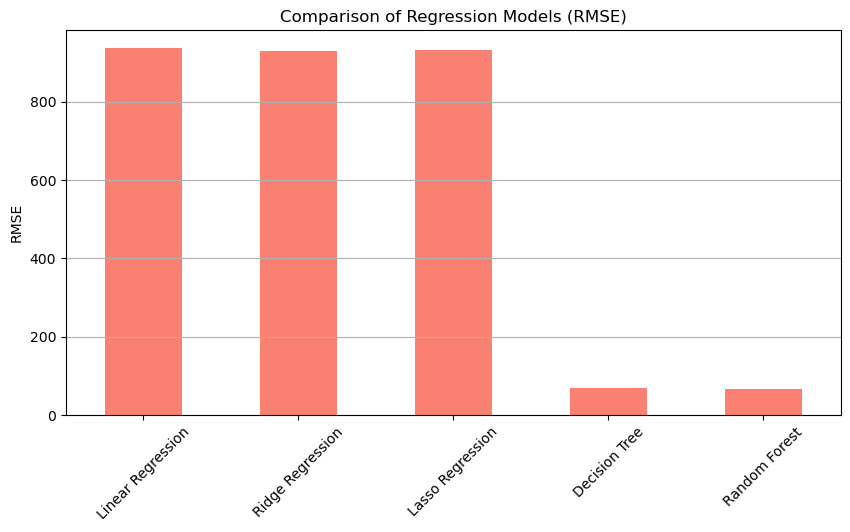

In [17]:
plt.figure(figsize=(10,5))
results_df['RMSE'].plot(kind='bar', color='salmon')
plt.title('Comparison of Regression Models (RMSE)')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()